#### Semi-supervised learning
- Supervised:   라벨 O 데이터만 사용
- Unsupervised: 라벨 없이 패턴만 찾음
- Semi:         라벨 O 조금 + 라벨 X 많이 → 같이 활용

- 라벨 다는 비용이 클 때 (의료, 법률 데이터)
- 라벨 없는 데이터는 많을 때
- 라벨 있는 데이터가 너무 적어서 supervised만으론 부족할 때
- 라벨 있는 데이터가 충분하거나, 라벨 없는 데이터가 분포가 다를 때는 사용하지 않음

- Self-Training
    - 라벨 있는 데이터로 모델 학습
    - 라벨 없는 데이터 예측
    - 확신도 높은 것만 라벨 달아서 훈련셋에 추가
    - 반복
- Label Propagation
    - 비슷한 샘플끼리는 같은 라벨로 가정: 그래프로 연결해서 라벨을 전파

  - LabelPropagation  → 라벨 있는 데이터는 절대 안 바뀜 (hard clamp)
  - LabelSpreading    → 라벨 있는 데이터도 살짝 바뀔 수 있음 (soft clamp), 노이즈 있는 경우, 현실적
  - 알고리즘 동작 비교
    1. 모든 샘플을 노드로 그래프 구성
    2. 비슷한 샘플끼리 엣지 연결 (kernel로 유사도 계산)
    3. 라벨 있는 노드 → 없는 노드로 라벨 전파
    4. rbf (gamma): 모든 샘플과 거리 기반 유사도 계산하며, 데이터 작을 때 유리
    5. knn (n_neighbors): 가장 가까운 k개에만 전파, 데이터 클 때 유리 (계산 효율)
  - 차이점
      - LabelPropagation: 전파 중 라벨 있는 노드 건드리면 → 원래 라벨로 강제 복원, 라벨 있는 것은 항상 고정
      - LabelSpreading: 전파 중 라벨 있는 노드도 alpha 비율만큼 이웃 영향 받음, 라벨 있는 것도 조금씩 변할 수 있음
       - alpha=0.0 : 이웃 무시, 원래 라벨 100% 유지 (LP와 동일)
       - alpha=0.2 : 원래 라벨 80% + 이웃 전파 20%
       - alpha=0.8 : 원래 라벨 20% + 이웃 전파 80%
       - alpha=1.0 : 원래 라벨 완전 무시

##### self-training

In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------------------------
# 1. CSV 읽기
# -----------------------------------------------
df = pd.read_csv('data.csv')  # 파일명 수정

X = df.drop(columns=['Pass.Fail']).values  # y 컬럼명 수정
y = df['Pass.Fail'].values

# -----------------------------------------------
# 2. train/test split
# -----------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------
# 3. 훈련셋 일부를 라벨 없음(-1)으로 처리
# -----------------------------------------------
UNLABELED_RATIO = 0.8  # 훈련셋의 80%를 라벨 없음으로

y_train_partial = y_train.copy()
n_unlabeled = int(len(y_train) * UNLABELED_RATIO)
unlabeled_idx = np.random.choice(len(y_train), size=n_unlabeled, replace=False)
y_train_partial[unlabeled_idx] = -1

labeled_idx = y_train_partial != -1
print(f"training set  : {len(y_train)}개")
print(f"training with label : {labeled_idx.sum()}개")
print(f"training without label : {(~labeled_idx).sum()}개")

# -----------------------------------------------
# 4. 모델 학습
# -----------------------------------------------

# [1] Supervised - 라벨 있는 것만
gbm_labeled = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm_labeled.fit(X_train[labeled_idx], y_train[labeled_idx])

# [2] Self-Training - 라벨 없는 것도 활용
self_training = SelfTrainingClassifier(
    estimator=GradientBoostingClassifier(n_estimators=100, random_state=42),
    threshold=0.8,
    max_iter=10
)
#1. estimator(GBM)로 라벨 있는 것 학습
#2. 라벨 없는 것 예측
#3. 확신도 > threshold(0.8) 인 것만 라벨 달아서 훈련셋에 추가
#4. 다시 estimator로 학습
#5. max_iter만큼 반복

self_training.fit(X_train, y_train_partial)


# [3] Supervised - 전체 라벨 (상한선 참고용)
gbm_full = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm_full.fit(X_train, y_train)

# -----------------------------------------------
# 5. 결과 비교
# -----------------------------------------------
models = {
    'Supervised (라벨 20%만)' : gbm_labeled,
    'Self-Training (라벨 20% + 무라벨 80%)': self_training,
    'Supervised (전체라벨, 상한선)': gbm_full,
}

print("\n" + "="*55)
print(f"{'모델':<40} {'정확도':>10}")
print("="*55)
for name, model in models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name:<40} {acc:>10.4f}")
print("="*55)

# 상세 리포트 (Self-Training)
print("\n[Self-Training result]")
print(classification_report(y_test, self_training.predict(X_test)))

training set  : 1253개
training with label : 251개
training without label : 1002개

모델                                              정확도
Supervised (라벨 20%만)                         0.9076
Self-Training (라벨 20% + 무라벨 80%)             0.9108
Supervised (전체라벨, 상한선)                       0.9172

[Self-Training result]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       293
           1       0.18      0.10      0.12        21

    accuracy                           0.91       314
   macro avg       0.56      0.53      0.54       314
weighted avg       0.89      0.91      0.90       314




##### Label Propagation

In [11]:
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.metrics import accuracy_score

# 위 코드에서 이어서 실행 (X_train, X_test, y_train_partial, y_test 재사용)

# LabelPropagation
lp = LabelPropagation(
    kernel='rbf',
    gamma=20,
    max_iter=1000
)
lp.fit(X_train, y_train_partial)
lp_acc = accuracy_score(y_test, lp.predict(X_test))
print(f"LabelPropagation accuracy: {lp_acc:.4f}")

# LabelSpreading
ls = LabelSpreading(
    kernel='knn',
    n_neighbors=7,
    alpha=0.2,
    max_iter=1000
)
ls.fit(X_train, y_train_partial)
ls_acc = accuracy_score(y_test, ls.predict(X_test))
print(f"LabelSpreading  accuracy: {ls_acc:.4f}")

LabelPropagation accuracy: 0.9331
LabelSpreading  accuracy: 0.9140


c:\Users\user\miniconda3\envs\day3\Lib\site-packages\sklearn\semi_supervised\_label_propagation.py:231: RuntimeWarning: invalid value encountered in divide
  probabilities /= normalizer


#### Tree SHAP

- 트리 구조를 직접 탐색해서 각 feature의 기여도를 계산함. 근사가 아니라 정확한 값임.
- 일반 SHAP은 feature n개면 2^n 조합 계산해야 함. TreeSHAP은 트리 탐색하면서 동시에 처리 → 다항시간으로 감소
- Shapley Value: feature를 포함/제외했을 때 예측 차이를 모든 조합에 대해 평균낸 값. 양수면 예측 올리는 방향, 음수면 내리는 방향으로 기여
- 기준값(전체 평균) + 모든 feature의 SHAP 합 = 해당 샘플 예측값
- 시각화
    - Summary plot → 전체 데이터 기준 feature 중요도 + 방향
    - Waterfall plot → 샘플 하나의 예측을 feature별로 분해
    - Dependence plot → 특정 feature 값과 SHAP 값의 관계

- 주의
    - 이진분류 → shap_values 바로 사용
    - 다중분류 → shap_values[클래스인덱스] 로 접근

In [13]:
!pip install shap -q

Test accuracy: 0.9172
shap_values shape: (314, 48)


<Figure size 640x480 with 0 Axes>

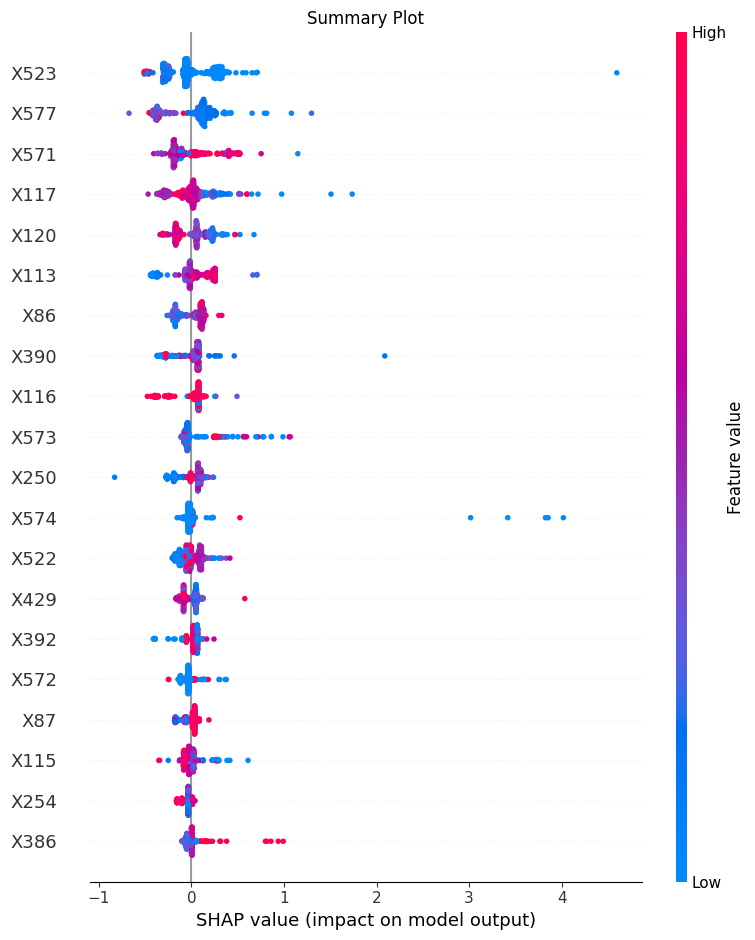

In [16]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

df = pd.read_csv('data.csv')  # 파일명 수정

X = df.drop(columns=['Pass.Fail'])
y = df['Pass.Fail']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------------------------
# 학습
# -----------------------------------------------
model = GradientBoostingClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"Test accuracy: {model.score(X_test, y_test):.4f}")

# -----------------------------------------------
# SHAP 계산
# -----------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)  # X_test 전체에 대해 계산

# 이진분류면 shap_values 그대로
# 다중분류면 shap_values[클래스인덱스] 로 접근
print(f"shap_values shape: {np.array(shap_values).shape}")

# -----------------------------------------------
# Summary Plot (전체 feature 중요도)
# -----------------------------------------------
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title("Summary Plot")
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

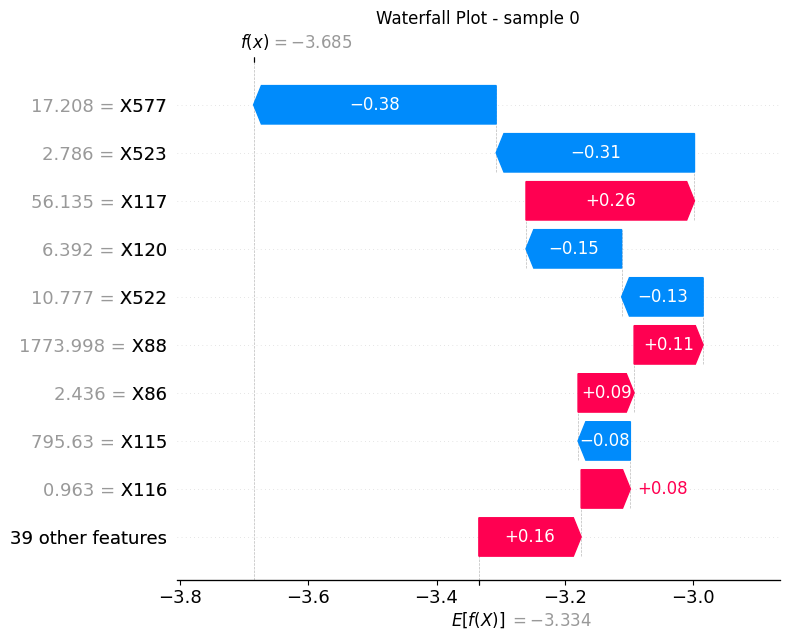

In [21]:
# -----------------------------------------------
# Waterfall Plot (개별 샘플 설명)
# -----------------------------------------------
sample_idx = 0  # 설명할 샘플 인덱스

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=float(explainer.expected_value[0]),
    data=X_test.iloc[sample_idx].values,
    feature_names=feature_names
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.title(f"Waterfall Plot - sample {sample_idx}")
plt.tight_layout()
plt.show()



가장 중요한 feature: X523


<Figure size 640x480 with 0 Axes>

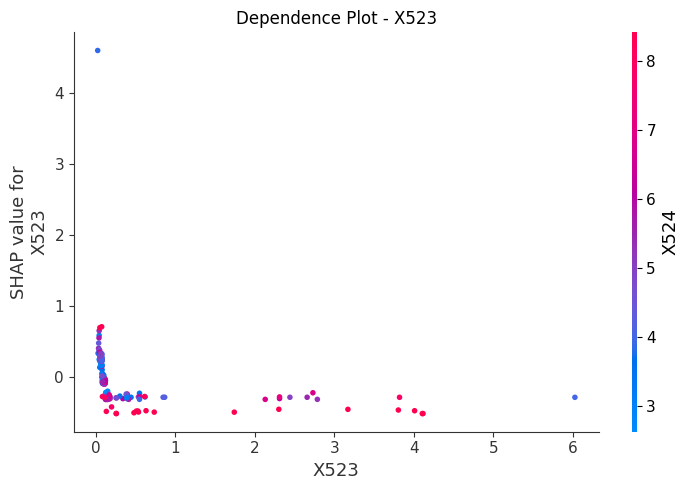

In [23]:
# -----------------------------------------------
# Dependence Plot (feature별 영향)
# -----------------------------------------------
# 가장 중요한 feature 자동 선택
top_feature = feature_names[np.abs(shap_values).mean(axis=0).argmax()]
print(f"가장 중요한 feature: {top_feature}")

plt.figure()
shap.dependence_plot(
    top_feature,
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title(f"Dependence Plot - {top_feature}")
plt.tight_layout()
plt.show()

In [24]:
# -----------------------------------------------
# SHAP value 데이터프레임으로 저장
# -----------------------------------------------
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_df.index = X_test.index
print("\n[SHAP values 상위 5행]")
print(shap_df.head())


[SHAP values 상위 5행]
           X20       X86       X87       X88      X113      X115      X116  \
246  -0.033338  0.087286  0.019616  0.107502  0.005221 -0.081495  0.076675   
1315  0.438509  0.093703  0.035954  0.026159  0.256293 -0.046030  0.075519   
444  -0.017161 -0.089518  0.013268  0.028002 -0.032234 -0.028123  0.067115   
296  -0.015717 -0.154080  0.013268 -0.045144  0.254960 -0.021169  0.080324   
1295 -0.034567  0.098990  0.035366 -0.048010  0.236136  0.295583  0.072089   

          X117      X119      X120  ...      X526      X527      X570  \
246   0.262397  0.048772 -0.148951  ... -0.002098 -0.003326  0.021636   
1315 -0.106357 -0.012390  0.232934  ... -0.001688 -0.001058  0.019351   
444  -0.292437 -0.036206 -0.003667  ...  0.079339  0.000486 -0.024166   
296   0.010201 -0.065014 -0.163259  ... -0.003914  0.000486 -0.024166   
1295  0.018102  0.076271 -0.150290  ... -0.002111 -0.001264 -0.049175   

          X571      X572      X573      X574      X575      X576      X